In [1]:
# --------------------------
# Step 1: Import Libraries
# --------------------------
import pandas as pd      # For CSV loading and data manipulation
import numpy as np       # For numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns    # Stylish plotting
from pathlib import Path # File path management

# Optional: make plots look nicer
sns.set(style="whitegrid")


In [7]:
# -----------------------------
# Step 1.5 Dummy Data
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# PARAMETERS
# -----------------------------
total_frames = 216           # Total frames / time points
sampling_interval = 1        # Hours between frames
np.random.seed(42)           # For reproducibility

# -----------------------------
# TIME VECTOR
# -----------------------------
ZT = np.arange(0, total_frames, sampling_interval)  # ZT0 → ZT215

rows = []

for time in ZT:
    
    # -----------------------------
    # BODY AREA (Nocturnal: expanded at night)
    # Peak expansion around ZT18 (middle of night)
    # -----------------------------
    body_baseline = 5000       # baseline area in pixels
    body_amplitude = 800       # circadian amplitude
    
    # Sinusoidal nocturnal pattern: shifted by 12 hours so peak is at night
    body_area = body_baseline + \
                body_amplitude * np.sin(2 * np.pi * (time - 12) / 24) + \
                np.random.normal(0, 200)  # add some noise
    
    rows.append({
        "ZT": time,
        "Label": "Body",
        "Area": body_area,
        "Perimeter": body_area * 0.08 + np.random.normal(0, 5)
    })

# -----------------------------
# CREATE DATAFRAME
# -----------------------------
dummy_body_data = pd.DataFrame(rows)

# -----------------------------
# SAVE TO CSV
# -----------------------------
dummy_body_data.to_csv("../csv/dummy_nocturnal_body_only.csv", index=False)

print("Nocturnal dummy BODY dataset created!")
print(dummy_body_data.head())



Nocturnal dummy BODY dataset created!
   ZT Label         Area   Perimeter
0   0  Body  5099.342831  407.256105
1   1  Body  4922.482472  401.413747
2   2  Body  4553.169325  363.082861
3   3  Body  4750.157138  383.849745
4   4  Body  4213.284800  339.775584


In [2]:
# --------------------------
# Step 1.75: Load CSV file from the 'csv' folder
# --------------------------
import pandas as pd

# Load the dummy dataset (body only) and assign to 'all_data'
all_data = pd.read_csv("../csv/dummy_nocturnal_body_only.csv")

# Peek at the first few rows
all_data.head()


,ZT,Label,Area,Perimeter
0,0,Body,5099.342831,407.256105
1,1,Body,4922.482472,401.413747
2,2,Body,4553.169325,363.082861
3,3,Body,4750.157138,383.849745
4,4,Body,4213.284800,339.775584


In [ ]:
# --------------------------
# Step 2: Load all CSV files from the 'csv' folder
# --------------------------
#csv_folder = Path("../csv")  # Adjust path relative to notebook location
#csv_files = list(csv_folder.glob("*.csv"))  # Collect all CSV files in the folder
#data_dict = {}  # Empty dictionary to store each DataFrame

# Loop over CSV files and load them into a dictionary
#for file in csv_files:
#    df = pd.read_csv(file)  # Load CSV into DataFrame
#    ZT = int(file.stem.split("_ZT")[1])  # Extract ZT from filename (e.g., ZT001)
#    df["ZT"] = ZT  # Add ZT as a new column
#    data_dict[file.stem] = df  # Store the DataFrame in the dictionary using the filename as key

# Combine all data into one large DataFrame
#all_data = pd.concat(data_dict.values(), ignore_index=True)
#all_data.head()  # Show the first few rows of the combined DataFrame


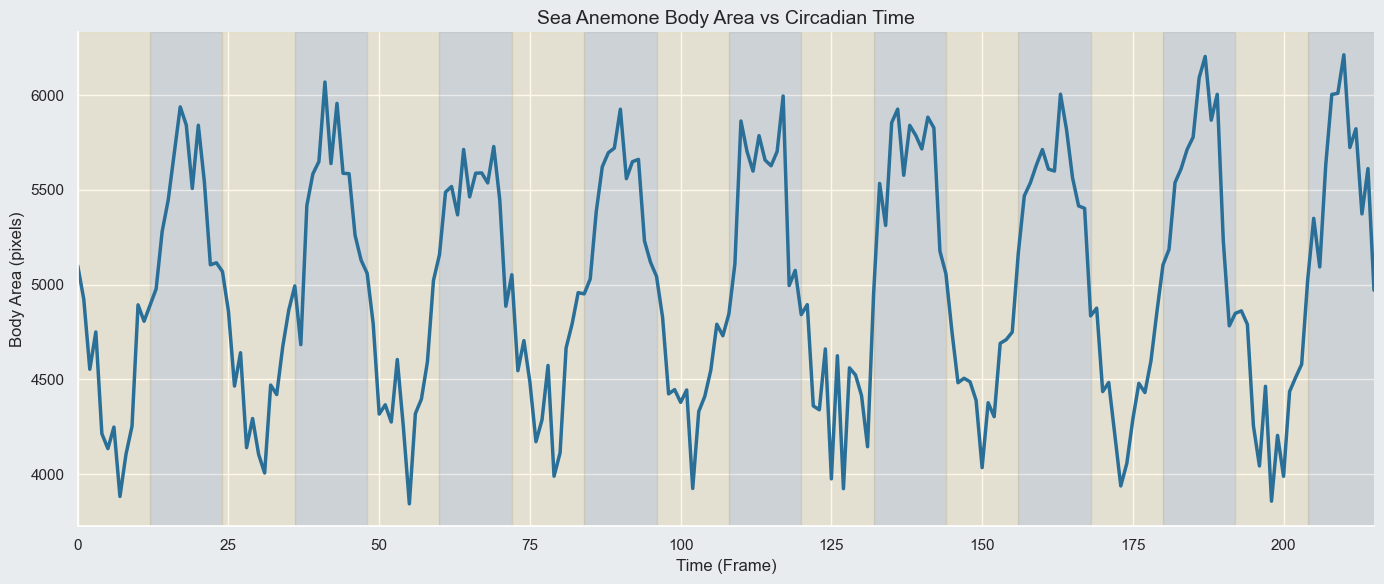

In [3]:
# --------------------------
# Step 3: Plot Body Area vs Frame (Circadian Time)
# --------------------------

# Filter the data for "Body" measurements
body_data = all_data[all_data['Label'] == 'Body']

# Set seaborn theme to match darker aesthetic
sns.set_theme(style="darkgrid")

# Create figure with soft background
plt.figure(figsize=(14,6), facecolor="#e9ecef")
ax = plt.gca()
ax.set_facecolor("#dfe3e6")

# Plot body area
sns.lineplot(
    x="ZT",
    y="Area",
    data=body_data,
    linewidth=2.5,
    color="#2a6f97"
)

# --------------------------
# Light / Dark Shading
# Light phase = frames 0–12
# Dark phase = frames 12–24
# Repeat every 24 frames
# --------------------------
for i in range(0, 216, 24):
    plt.axvspan(i, i+12, color="#ffd166", alpha=0.15)
    plt.axvspan(i+12, i+24, color="#6c757d", alpha=0.15)

# Labeling
plt.xlabel("Time (Frame)", fontsize=12)
plt.ylabel("Body Area (pixels)", fontsize=12)
plt.title("Sea Anemone Body Area vs Circadian Time", fontsize=14)

# Clean up axes
plt.xlim(0, 215)
sns.despine()

plt.tight_layout()
plt.show()



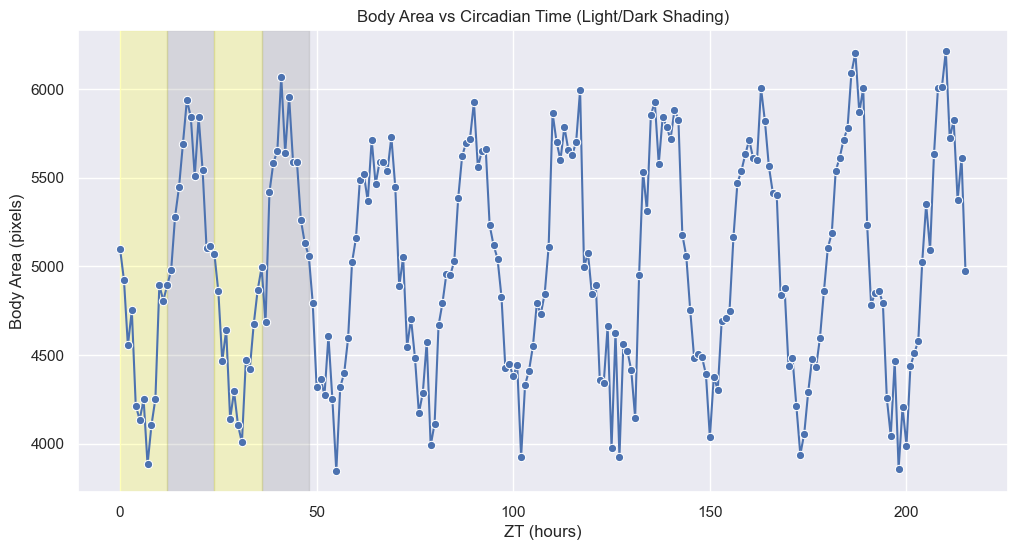

In [4]:
# --------------------------
# Step 4: Overlay light/dark phases on Body Area plot
# --------------------------

# Create the Body Area plot again, but with shaded light/dark phases
plt.figure(figsize=(12,6))
sns.lineplot(x="ZT", y="Area", data=body_data, marker='o')

# Shade the light/dark phases. Light = ZT0-12, Dark = ZT12-24
for i in range(0, 36, 24):  # Loop over 24-hour intervals (e.g., days)
    plt.axvspan(i, i+12, color='yellow', alpha=0.2)  # Light phase: yellow
    plt.axvspan(i+12, i+24, color='gray', alpha=0.2)  # Dark phase: gray

# Labeling and displaying the plot
plt.xlabel("ZT (hours)")
plt.ylabel("Body Area (pixels)")
plt.title("Body Area vs Circadian Time (Light/Dark Shading)")

# Show the plot
plt.show()

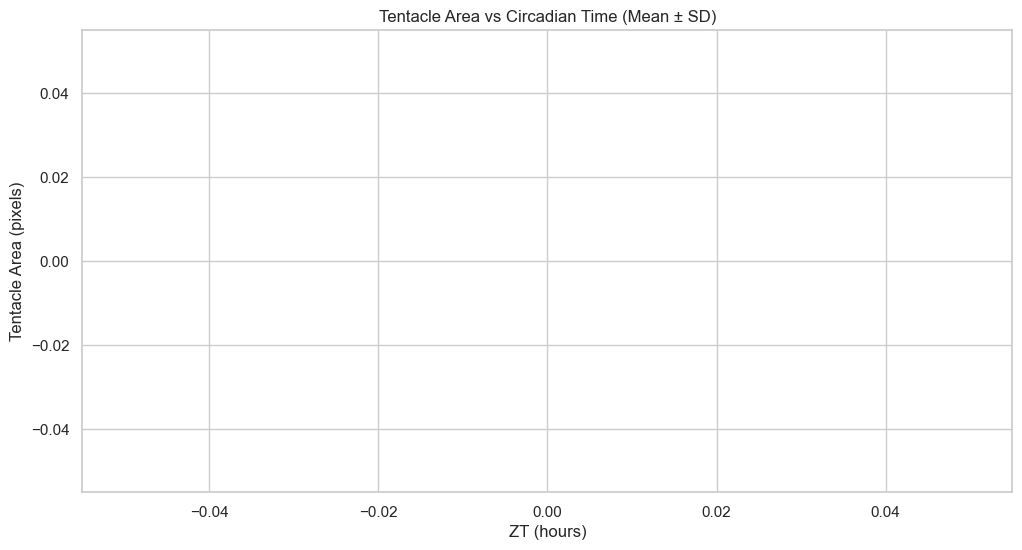

In [12]:
# --------------------------
# Step 5: Tentacle Area Analysis (Mean ± SD)
# --------------------------

# Filter the data for "Tentacle" measurements
tentacles = all_data[all_data['Label'] == 'Tentacle']

# Plot mean tentacle area ± standard deviation
plt.figure(figsize=(12,6))
sns.lineplot(x="ZT", y="Area", data=tentacles, errorbar='sd', marker='o')

# Labeling the plot
plt.xlabel("ZT (hours)")
plt.ylabel("Tentacle Area (pixels)")
plt.title("Tentacle Area vs Circadian Time (Mean ± SD)")

# Show the plot
plt.show()

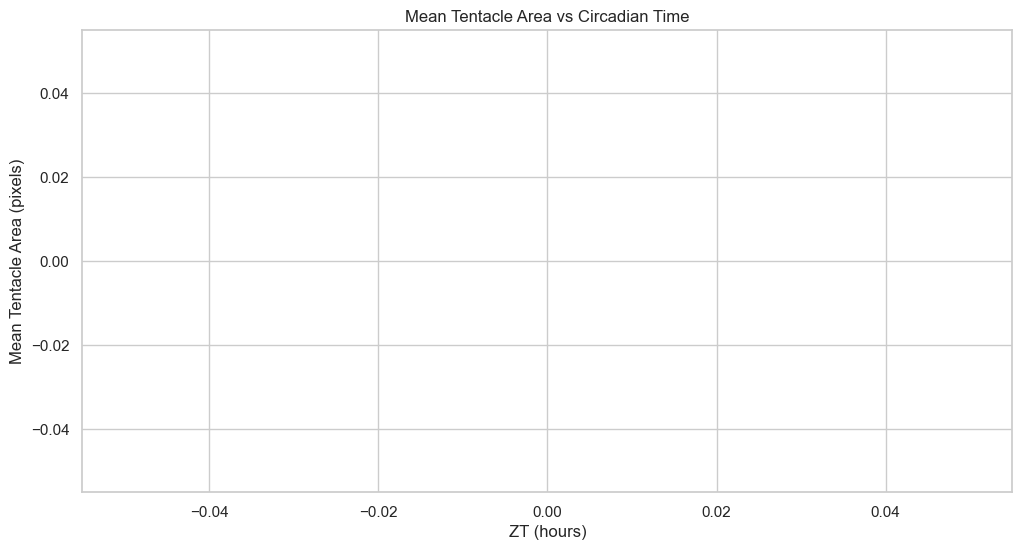

In [13]:
# --------------------------
# Step 6: Average Tentacle Area per ZT
# --------------------------

# Group the data by ZT and calculate the mean tentacle area for each ZT
tentacle_mean = tentacles.groupby("ZT")["Area"].mean().reset_index()

# Plot average tentacle area across ZT
plt.figure(figsize=(12,6))
sns.lineplot(x="ZT", y="Area", data=tentacle_mean, marker='o')

# Labeling the plot
plt.xlabel("ZT (hours)")
plt.ylabel("Mean Tentacle Area (pixels)")
plt.title("Mean Tentacle Area vs Circadian Time")

# Show the plot
plt.show()


In [ ]:
# --------------------------
# Step 7: Save processed combined data to CSV
# --------------------------

# Export the combined DataFrame to a CSV file in the root project folder
all_data.to_csv("../processed_anemone_data.csv", index=False)

# Confirm the export
print("Processed data saved as 'processed_anemone_data.csv'")


In [ ]:
# --------------------------
# Step 8: Separate Graphs for Body Area and Tentacle Area with Light/Dark Shading
# --------------------------

# Function to add light/dark shading to the plot
def add_light_dark_shading():
    # Shading for the light (yellow) and dark (gray) phases
    for i in range(0, 36, 24):  # Loop over the 24-hour intervals
        plt.axvspan(i, i + 12, color='yellow', alpha=0.2)  # Light phase (ZT0-ZT12)
        plt.axvspan(i + 12, i + 24, color='gray', alpha=0.2)  # Dark phase (ZT12-ZT24)

# Plot Body Area with Light/Dark shading
plt.figure(figsize=(12,6))
add_light_dark_shading()  # Add the shading for light and dark periods
sns.lineplot(x="ZT", y="Area", data=body_data, label="Body Area", color='blue', marker='o')
plt.xlabel("ZT (hours)")
plt.ylabel("Body Area (pixels)")
plt.title("Body Area vs Circadian Time (ZT) with Light/Dark Shading")
plt.grid(True)
plt.show()

# Plot Tentacle Area with Light/Dark shading
plt.figure(figsize=(12,6))
add_light_dark_shading()  # Add the shading for light and dark periods
sns.lineplot(x="ZT", y="Area", data=tentacle_data, label="Tentacle Area", color='green', marker='o')
plt.xlabel("ZT (hours)")
plt.ylabel("Tentacle Area (pixels)")
plt.title("Tentacle Area vs Circadian Time (ZT) with Light/Dark Shading")
plt.grid(True)
plt.show()


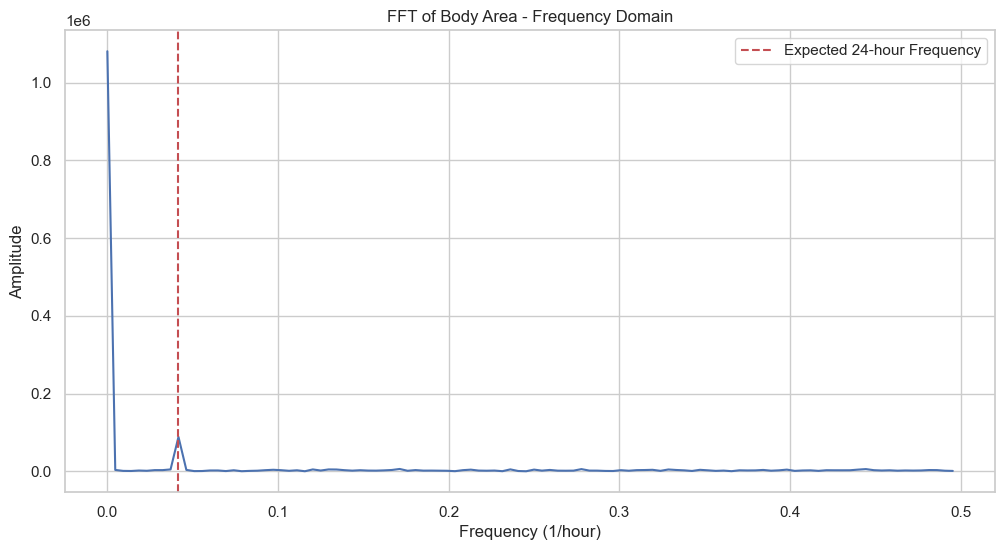

Peak Frequency: 0.0 1/hour
Peak Period: inf hours


In [14]:
# --------------------------
# Step 9: FFT Analysis to Detect 24-hour Periodicity
# --------------------------

import numpy as np

# Choose the data for FFT analysis (e.g., Body Area)
# You can change this to tentacle_data if you'd like to analyze tentacle area
data_for_fft = body_data.groupby("ZT")["Area"].mean()

# Perform FFT
fft_result = np.fft.fft(data_for_fft)

# Get the corresponding frequencies
frequencies = np.fft.fftfreq(len(data_for_fft), d=1)  # d=1 because we have 1 data point per hour

# Only keep the positive frequencies
positive_freqs = frequencies[:len(frequencies)//2]
positive_fft = np.abs(fft_result[:len(frequencies)//2])

# Identify the peak frequency
peak_freq_index = np.argmax(positive_fft)
peak_freq = positive_freqs[peak_freq_index]

# Convert peak frequency to period (in hours)
peak_period = 1 / peak_freq if peak_freq != 0 else np.inf  # 1/frequency gives the period

# Plot the FFT result
plt.figure(figsize=(12,6))
plt.plot(positive_freqs, positive_fft)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Amplitude")
plt.title("FFT of Body Area - Frequency Domain")
plt.grid(True)

# Highlight the peak frequency (where we expect the 24-hour period)
plt.axvline(x=1/24, color='r', linestyle='--', label="Expected 24-hour Frequency")
plt.legend()

# Display results
plt.show()

# Print the results
print(f"Peak Frequency: {peak_freq} 1/hour")
print(f"Peak Period: {peak_period} hours")


In [ ]:
# --------------------------
# Step 10: Save FFT Results and Visualize Dominant Frequency
# --------------------------

# Save the FFT results (frequencies and amplitudes) to a CSV file
fft_results_df = pd.DataFrame({
    "Frequency (1/hour)": positive_freqs,
    "Amplitude": positive_fft
})

# Save the FFT results to a CSV file for further analysis
fft_results_df.to_csv("../fft_results.csv", index=False)

# Print confirmation message
print("FFT results saved as 'fft_results.csv'")

# Highlight the frequency with the highest amplitude on the FFT plot
plt.figure(figsize=(12,6))
plt.plot(positive_freqs, positive_fft, label="FFT Amplitude")
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Amplitude")
plt.title("FFT of Body Area - Frequency Domain")
plt.grid(True)

# Mark the peak frequency (dominant frequency) with a vertical line
plt.axvline(x=peak_freq, color='r', linestyle='--', label=f"Peak Frequency: {peak_freq:.2f} 1/hour")
plt.axvline(x=1/24, color='orange', linestyle='--', label="Expected 24-hour Frequency (1/24 Hz)")

# Add the legend to explain the lines
plt.legend()

# Display the updated plot
plt.show()

# Display the first few rows of the FFT results
fft_results_df.head()
